In [ ]:
!pip install torch torchvision matplotlib pillow

In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image

from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    FasterRCNN_ResNet50_FPN_Weights
)


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [ ]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT

model = fasterrcnn_resnet50_fpn(
    weights=weights
)

model = model.to(device)

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
COCO_CLASSES = weights.meta["categories"]

print("\nNumber of classes:", len(COCO_CLASSES))

print("\nImportant class IDs:")
print("Dog   =", COCO_CLASSES.index("dog"))
print("Horse =", COCO_CLASSES.index("horse"))


Number of classes: 91

Important class IDs:
Dog   = 18
Horse = 19


In [ ]:
transform = weights.transforms()

In [ ]:
import urllib.request

image_url = (
    "https://raw.githubusercontent.com/"
    "pytorch/hub/master/images/dog.jpg"
)

image_path = "dog.jpg"

urllib.request.urlretrieve(
    image_url,
    image_path
)

print("\nImage downloaded successfully!")


Image downloaded successfully!


In [ ]:
image = Image.open(
    image_path
).convert("RGB")


print("Image size:", image.size)

Image size: (1546, 1213)


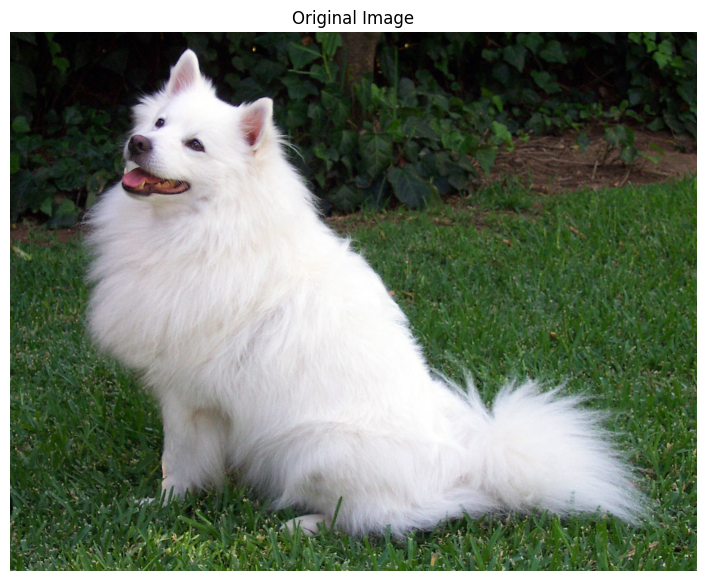

In [ ]:
plt.figure(figsize=(10, 7))

plt.imshow(image)

plt.axis("off")

plt.title("Original Image")

plt.show()

In [ ]:
image_tensor = transform(image)

image_tensor = image_tensor.to(device)

print("\nImage Tensor Shape:")
print(image_tensor.shape)


Image Tensor Shape:
torch.Size([3, 1213, 1546])


In [ ]:
with torch.no_grad():

    predictions = model(
        [image_tensor]
    )

In [ ]:
prediction = predictions[0]

boxes = prediction["boxes"]
labels = prediction["labels"]
scores = prediction["scores"]

In [ ]:
print("PREDICTIONS")

for i in range(min(20, len(scores))):

    label_id = labels[i].item()

    class_name = COCO_CLASSES[label_id]

    confidence = scores[i].item()

    print(
        f"{i+1:2d}. "
        f"ID: {label_id:2d} | "
        f"{class_name:15s} | "
        f"Confidence: {confidence:.4f}"
    )

PREDICTIONS
 1. ID: 18 | dog             | Confidence: 0.9669
 2. ID: 17 | cat             | Confidence: 0.3522
 3. ID: 34 | frisbee         | Confidence: 0.3132
 4. ID: 18 | dog             | Confidence: 0.1133


In [ ]:
confidence_threshold = 0.50

keep = scores >= confidence_threshold


boxes_filtered = boxes[keep]

labels_filtered = labels[keep]

scores_filtered = scores[keep]


In [ ]:
print("\n========================================")
print("DETECTED OBJECTS")
print("========================================")

if len(scores_filtered) == 0:

    print("No objects detected.")

else:

    for label, score in zip(
        labels_filtered,
        scores_filtered
    ):

        label_id = label.item()

        class_name = COCO_CLASSES[label_id]

        print(
            f"{class_name:15s} "
            f"Confidence: {score.item():.2f}"
        )


DETECTED OBJECTS
dog             Confidence: 0.97


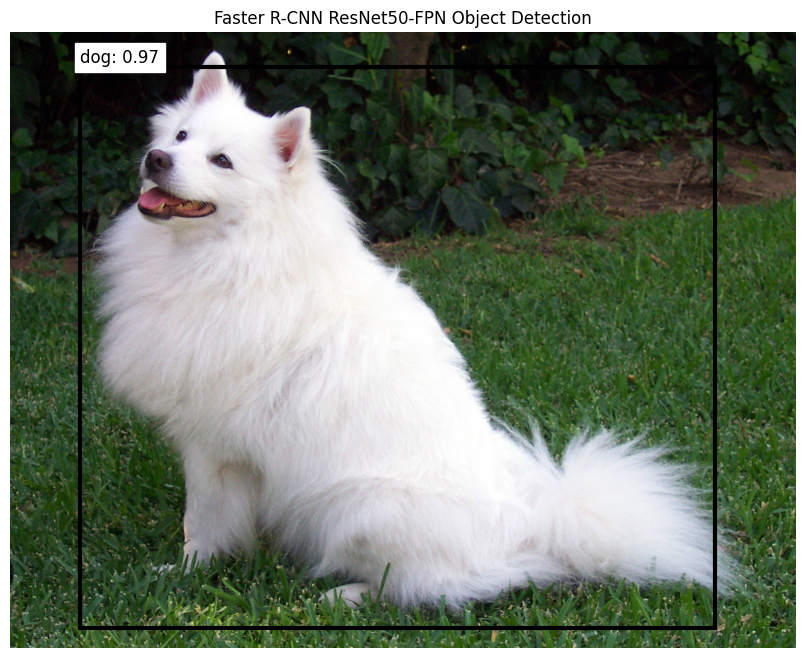

In [ ]:
plt.figure(figsize=(12, 8))

plt.imshow(image)

ax = plt.gca()


for box, label, score in zip(
    boxes_filtered,
    labels_filtered,
    scores_filtered
):

    # Convert box to CPU
    box = box.detach().cpu().numpy()

    x1, y1, x2, y2 = box

    width = x2 - x1

    height = y2 - y1




    rectangle = patches.Rectangle(
        (x1, y1),
        width,
        height,
        fill=False,
        linewidth=3
    )

    ax.add_patch(rectangle)




    label_id = label.item()

    class_name = COCO_CLASSES[label_id]



    text = (
        f"{class_name}: "
        f"{score.item():.2f}"
    )


    ax.text(
        x1,
        max(y1 - 8, 5),
        text,
        fontsize=12,
        backgroundcolor="white"
    )
plt.axis("off")

plt.title(
    "Faster R-CNN ResNet50-FPN Object Detection"
)

plt.show()